# Data Exploration — Diabetes 130-US Hospitals (1999–2008)

Goal: understand the structure and quality of the two raw files before cleaning.  

**Files**
* diabetic_data.csv — one row per hospital encounter
* IDS_mapping.csv — lookup descriptions for the admission_type_id, discharge_disposition_id, and admission_source_id columns in diabetic_data.csv

**Notebook layout**
* **Part A — Pre-EDA data quality checks:** problems in the raw layout that must be fixed before any EDA
* **Section 9:** summary of pre-EDA issues and cleaning decisions.
* **Section 10:** apply the cleaning and save `data/diabetic_data_clean.csv` for further EDA.

# Part A — Pre-EDA data quality checks

## 1. Setup & load

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)

# Load dataset #1
df = pd.read_csv("../data/diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [24]:
df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,MC,?,51,0,16,0,0,0,250.13,291,458,9,NaN,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,MC,?,33,3,18,0,0,1,560,276,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,MC,?,53,0,9,1,0,0,38,590,296,13,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,?,?,13,3,3,0,0,0,530,530,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO


## 2. Structure

In [25]:
df.shape  # 101,766 rows, 50 columns

(101766, 50)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

#### Structure observations
* Missing values appear in **two forms**:
  * the string `'?'` (e.g. `weight`, `race`, `payer_code`). Pandas treats these as real values, so `df.info()` reports them as non-null.
  * `NaN` in `max_glu_serum` and `A1Cresult`. The raw file stores the text `None` there (meaning *test not performed*), and pandas converts `None` to NaN on load by default.
* **`df.info()` is misleading**: it says every column is non-null except `max_glu_serum` and `A1Cresult`, but many columns contain `'?'`.
* `age` and `weight` are stored as bracketed ranges such as `[70-80)` — `[` means inclusive and `)` means exclusive so they are ordinal categories, not numbers

In [27]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


`df.describe()` picks up **13 numeric columns** when the dataset only has **8 true numeric columns**:
* `encounter_id` and `patient_nbr` are identifiers. Their mean/std are meaningless.
* `admission_type_id`, `discharge_disposition_id`, `admission_source_id` are **categorical codes**. Each number stands for a category described in `IDS_mapping.csv`

## 3. Column types

Based on the UCI variable table dictionary we expect:
* **40 categorical variables** (including the 3 coded `*_id` columns)
* **8 integer (numeric) variables**
* **2 ID variables**

In [28]:
# Define groups once so we can reuse later to check that we have the right number of each column

id_cols = ['encounter_id', 'patient_nbr']

numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
                'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

code_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']

med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
            'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol',
            'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

categorical_cols = [c for c in df.columns if c not in id_cols + numeric_cols]

print(f"ID: {len(id_cols)}, numeric: {len(numeric_cols)}, categorical: {len(categorical_cols)}, "
      f"total: {len(id_cols) + len(numeric_cols) + len(categorical_cols)}")
print("\npandas dtypes:")
print(df.dtypes.value_counts())

ID: 2, numeric: 8, categorical: 40, total: 50

pandas dtypes:
str      37
int64    13
Name: count, dtype: int64


#### Observations
* pandas reads **13 columns as int64** (8 numeric + 2 IDs + 3 codes) and **37 as strings**.
* For cleaning, the 3 code columns and the 2 IDs should be treated as categorical / identifiers, not numbers.

## 4. Missing values

Missing percentage of every column, counting both forms of missing data: `'?'` placeholders and true NaN values.

In [29]:
pd.set_option('display.max_rows', None)  # show every row

missing = pd.DataFrame({
    'question_marks': (df == '?').sum(),
    'nan': df.isna().sum(),
})
missing['total'] = missing.sum(axis=1)
missing['pct'] = (missing['total'] / len(df) * 100).round(2)
missing.sort_values('pct', ascending=False)


,question_marks,nan,total,pct
weight,98569,0,98569,96.86
max_glu_serum,0,96420,96420,94.75
A1Cresult,0,84748,84748,83.28
medical_specialty,49949,0,49949,49.08
payer_code,40256,0,40256,39.56
race,2273,0,2273,2.23
diag_3,1423,0,1423,1.40
diag_2,358,0,358,0.35
diag_1,21,0,21,0.02
encounter_id,0,0,0,0.00


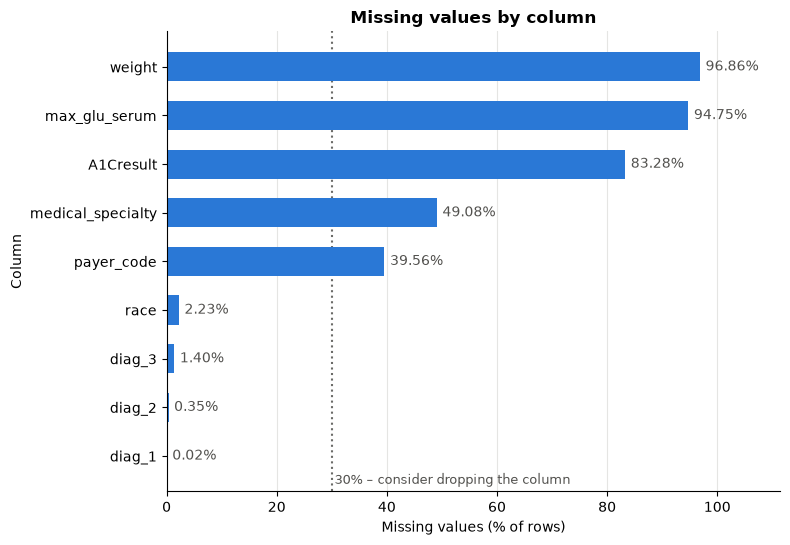

In [30]:
# Create missing values chart 

# Keep only the columns that have missing values
miss = missing.loc[missing['total'] > 0, 'pct'].sort_values()

fig, ax = plt.subplots(figsize=(8, 0.45 * len(miss) + 1.5))
bars = ax.barh(miss.index, miss.values, color='#2a78d6', height=0.6)

# Reference line at 30%
threshold = 30
ax.axvline(threshold, color='#6b6b68', linestyle=':', linewidth=1.5, zorder=0)
ax.text(threshold + 0.5, 0.01, f'{threshold}% – consider dropping the column',
        transform=ax.get_xaxis_transform(),  # x in data units, y relative to the axes
        ha='left', va='bottom', fontsize=9, color='#52514e')


# Data labels at the end of each bar
ax.bar_label(bars, labels=[f'{v:.2f}%' for v in miss.values],
             padding=4, fontsize=10, color='#52514e')

# Axis labels and title
ax.set_xlabel('Missing values (% of rows)')
ax.set_ylabel('Column')
ax.set_title('Missing values by column', loc='center', fontweight='bold')

# Tidy up: remove extra borders, add a light grid, leave room for the labels
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='#e5e5e3', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlim(0, miss.max() * 1.15)

plt.tight_layout()
plt.show()


#### Observations
| Column | Missing | Note |
|---|---|---|
| `weight` | ~97% `'?'` | too sparse to use; candidate to drop |
| `max_glu_serum` | ~95% NaN | NaN = test **not performed**, which is meaningful information, not a data error |
| `A1Cresult` | ~83% NaN |  NaN = test **not performed**, which is meaningful information, not a data error |
| `medical_specialty` | ~49% `'?'` | Nearly half the rows have no specialty recorded for the admitting doctor. Dropping those rows would lose half the dataset. Convert '?' to NaN now; decide whether to drop the column or fill with "Unknown" after EDA. A few non-missing values also carry no specialty (`PhysicianNotFound`, `Resident`, `DCPTEAM`) |
| `payer_code` | ~40% `'?'` | convert '?' to NaN now; after EDA, fill with "Unknown" if insurance type matters for readmission, otherwise drop the column. |
| `race` | ~2% `'?'` | small impact, fill '?' with "Unknown" |
| `diag_1` / `diag_2` / `diag_3` | 0.02% / 0.35% / 1.4% `'?'` | small impact |

In [31]:
# Are blank diag_2 / diag_3 really missing, or did the patient just have fewer diagnoses?
for c, n in [('diag_1', 1), ('diag_2', 2), ('diag_3', 3)]:
    blank = df[c] == '?'
    structural = blank & (df['number_diagnoses'] < n)  # patient had fewer than n diagnoses
    print(f"{c}: {blank.sum()} blank | {structural.sum()} structural (fewer than {n} diagnoses) | "
          f"{(blank & ~structural).sum()} actually missing")

diag_1: 21 blank | 0 structural (fewer than 1 diagnoses) | 21 actually missing
diag_2: 358 blank | 219 structural (fewer than 2 diagnoses) | 139 actually missing
diag_3: 1423 blank | 1242 structural (fewer than 3 diagnoses) | 181 actually missing


* Most blank `diag_2` / `diag_3` values are **structural**: the patient had fewer than 2 or 3 diagnoses, so there is no
  second / third diagnosis to record. Only ~140 `diag_2` and ~180 `diag_3` values are actually missing.
* Every encounter should have a primary diagnosis, so the **21 blank `diag_1`** rows are invalid records.

## 5. Invalid / unexpected values

List every distinct value of the low-cardinality categorical columns to catch typos, placeholders and invalid entries.

In [32]:
low_card = [c for c in categorical_cols if df[c].nunique(dropna=False) <= 12 and c not in med_cols]
for c in low_card:
    print(c, df[c].value_counts(dropna=False).to_dict(), '\n')

race {'Caucasian': 76099, 'AfricanAmerican': 19210, '?': 2273, 'Hispanic': 2037, 'Other': 1506, 'Asian': 641} 

gender {'Female': 54708, 'Male': 47055, 'Unknown/Invalid': 3} 

age {'[70-80)': 26068, '[60-70)': 22483, '[50-60)': 17256, '[80-90)': 17197, '[40-50)': 9685, '[30-40)': 3775, '[90-100)': 2793, '[20-30)': 1657, '[10-20)': 691, '[0-10)': 161} 

weight {'?': 98569, '[75-100)': 1336, '[50-75)': 897, '[100-125)': 625, '[125-150)': 145, '[25-50)': 97, '[0-25)': 48, '[150-175)': 35, '[175-200)': 11, '>200': 3} 

admission_type_id {1: 53990, 3: 18869, 2: 18480, 6: 5291, 5: 4785, 8: 320, 7: 21, 4: 10} 

max_glu_serum {nan: 96420, 'Norm': 2597, '>200': 1485, '>300': 1264} 

A1Cresult {nan: 84748, '>8': 8216, 'Norm': 4990, '>7': 3812} 

change {'No': 54755, 'Ch': 47011} 

diabetesMed {'Yes': 78363, 'No': 23403} 

readmitted {'NO': 54864, '>30': 35545, '<30': 11357} 



#### Observations
* `gender` contains **3 rows of `'Unknown/Invalid'`** — too few to model, candidate to drop
* `age` has 10 brackets from `[0-10)` to `[90-100)`, heavily weighted toward older patients
* `change` uses `Ch`/`No` and `diabetesMed` uses `Yes`/`No` → both can become 0/1

## 6. Duplicate rows

In [33]:
# Check if there are duplicate rows if we dropped the encounter_id and patient columns
print("Duplicate rows (ignoring encounter_id):", df.drop(columns=['encounter_id']).duplicated().sum())
print("Duplicate rows (ignoring encounter_id & patient):", df.drop(columns=id_cols).duplicated().sum())


Duplicate rows (ignoring encounter_id): 0
Duplicate rows (ignoring encounter_id & patient): 0


#### Observations
* `encounter_id` is unique, so a plain `df.duplicated()` would always return 0. Even ignoring the ID columns there are
  **no duplicate rows** → no encounter was recorded twice under a different ID.

## 7. The ID mapping file (dataset #2)

In [34]:
# Load dataset #2
df2 = pd.read_csv("../data/IDS_mapping.csv")

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df2)

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


`IDS_mapping.csv` is **three lookup tables stacked into one CSV**, separated by blank rows, each with its own header row.  
Pandas uses the first table's header for the whole file, so the column names are wrong and all values are strings.

To use it we need to split it into three clean tables (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`), strip whitespace from the descriptions and convert the IDs to integers.  
This is needed so that we can use the descriptions to interpret the 3 code columns in `diabetic_data.csv`.

In [35]:
# Split IDS_mapping.csv into 3 separate tables.

# keep_default_na=False keeps the literal text 'NULL' instead of turning it into NaN
raw = pd.read_csv("../data/IDS_mapping.csv", header=None, names=['id', 'description'],
                  dtype=str, keep_default_na=False)

# Find separator rows (both 'id' and 'description' are blank)
is_blank = (raw['id'].str.strip() == '') & (raw['description'].str.strip() == '')
block = is_blank.cumsum() # assign a block number to each row, incrementing at each blank separator row

# Loop over each table
lookups = {}
for _, part in raw[~is_blank].groupby(block[~is_blank]):
    # Clean each table
    name = part.iloc[0]['id'] # first row of each block is its header, e.g. 'admission_type_id'
    table = part.iloc[1:].copy()
    table['id'] = table['id'].astype(int)
    table['description'] = table['description'].str.strip()
    lookups[name] = table.rename(columns={'id': name}).reset_index(drop=True)

# Store tables into a dictionary
for name, table in lookups.items():
    print(name, table.shape)

admission_type_id (8, 2)
discharge_disposition_id (30, 2)
admission_source_id (25, 2)


In [36]:
# Check the cleaned lookup tables
lookups['admission_source_id']  # example: one clean lookup table

,admission_source_id,description
0,1,Physician Referral
1,2,Clinic Referral
2,3,HMO Referral
3,4,Transfer from a hospital
4,5,Transfer from a Skilled Nursing Facility (SNF)
5,6,Transfer from another health care facility
6,7,Emergency Room
7,8,Court/Law Enforcement
8,9,Not Available
9,10,Transfer from critial access hospital


In [37]:
lookups['admission_type_id']

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NULL
6,7,Trauma Center
7,8,Not Mapped


In [38]:
lookups['discharge_disposition_id']

,discharge_disposition_id,description
0,1,Discharged to home
1,2,Discharged/transferred to another short term h...
2,3,Discharged/transferred to SNF
3,4,Discharged/transferred to ICF
4,5,Discharged/transferred to another type of inpa...
5,6,Discharged/transferred to home with home healt...
6,7,Left AMA
7,8,Discharged/transferred to home under care of H...
8,9,Admitted as an inpatient to this hospital
9,10,Neonate discharged to another hospital for neo...


## 8. ID code columns and mapping

For each code column: how often each code occurs in the data, what it means, whether any codes are placeholders for
missing data, and whether the data and the mapping disagree.

In [39]:
# Define placeholder terms that were identified by manually reviewing the IDS_mapping.csv
placeholder_terms = ['NULL', 'Not Available', 'Not Mapped', 'Unknown/Invalid']

code_summary = {}
for col in code_cols:
    counts = df[col].value_counts().rename('n_rows').rename_axis(col).reset_index()
    merged = lookups[col].merge(counts, on=col, how='outer')
    merged['n_rows'] = merged['n_rows'].fillna(0).astype(int)
    merged['placeholder'] = merged['description'].isin(placeholder_terms)
    code_summary[col] = merged.sort_values(col).reset_index(drop=True)

In [40]:
code_summary['admission_type_id']

,admission_type_id,description,n_rows,placeholder
0,1,Emergency,53990,False
1,2,Urgent,18480,False
2,3,Elective,18869,False
3,4,Newborn,10,False
4,5,Not Available,4785,True
5,6,NULL,5291,True
6,7,Trauma Center,21,False
7,8,Not Mapped,320,True


In [41]:
with pd.option_context('display.max_colwidth', 80):
    display(code_summary['discharge_disposition_id'])

,discharge_disposition_id,description,n_rows,placeholder
0,1,Discharged to home,60234,False
1,2,Discharged/transferred to another short term hospital,2128,False
2,3,Discharged/transferred to SNF,13954,False
3,4,Discharged/transferred to ICF,815,False
4,5,Discharged/transferred to another type of inpatient care institution,1184,False
5,6,Discharged/transferred to home with home health service,12902,False
6,7,Left AMA,623,False
7,8,Discharged/transferred to home under care of Home IV provider,108,False
8,9,Admitted as an inpatient to this hospital,21,False
9,10,Neonate discharged to another hospital for neonatal aftercare,6,False


In [42]:
code_summary['admission_source_id']

,admission_source_id,description,n_rows,placeholder
0,1,Physician Referral,29565,False
1,2,Clinic Referral,1104,False
2,3,HMO Referral,187,False
3,4,Transfer from a hospital,3187,False
4,5,Transfer from a Skilled Nursing Facility (SNF),855,False
5,6,Transfer from another health care facility,2264,False
6,7,Emergency Room,57494,False
7,8,Court/Law Enforcement,16,False
8,9,Not Available,125,True
9,10,Transfer from critial access hospital,8,False


In [43]:
# Summary of placeholder codes and mapping issues
for col, s in code_summary.items():
    ph = s[s['placeholder']]
    print(col)
    print("  placeholder codes:", ph[col].tolist(), "->", ph['n_rows'].sum(), "rows")
    print("  in mapping, never used: ", s.loc[s['n_rows'] == 0, col].tolist())
    print("  in data, not in mapping: ", s.loc[s['description'].isna(), col].tolist())

admission_type_id
  placeholder codes: [5, 6, 8] -> 10396 rows
  in mapping, never used:  []
  in data, not in mapping:  []
discharge_disposition_id
  placeholder codes: [18, 25, 26] -> 4680 rows
  in mapping, never used:  [21, 26, 29, 30]
  in data, not in mapping:  []
admission_source_id
  placeholder codes: [9, 15, 17, 20, 21] -> 7067 rows
  in mapping, never used:  [12, 15, 18, 19, 21, 23, 24, 26]
  in data, not in mapping:  []


#### Observations
* **Placeholder ("unknown") codes:**
  * `admission_type_id` 5 (Not Available), 6 (NULL), 8 (Not Mapped) → ~10.4k rows
  * `discharge_disposition_id` 18 (NULL), 25 (Not Mapped) → ~4.7k rows (26 = Unknown/Invalid exists in the mapping but never occurs)
  * `admission_source_id` 9 (Not Available), 17 (NULL), 20 (Not Mapped) → ~7.1k rows (15 and 21 exist in the mapping but never occur)
  * These are missing values in disguise → collapse them into one "Unknown" category per column.
* `admission_source_id` has **two different codes that both mean "Not Available"** (9 and 15).
* Every code in the data has a description in the mapping, so a left merge will not create unmatched rows.
* Many mapping codes never occur in the data (e.g. newborn / delivery codes), which is expected for a diabetes cohort.

In [44]:
# Discharge codes where the patient died or went to hospice (these patients cannot be readmitted)
expired_hospice = [11, 13, 14, 19, 20, 21]
s = code_summary['discharge_disposition_id']
display(s[s['discharge_disposition_id'].isin(expired_hospice)])
print("Rows:", df['discharge_disposition_id'].isin(expired_hospice).sum())

,discharge_disposition_id,description,n_rows,placeholder
10,11,Expired,1642,False
12,13,Hospice / home,399,False
13,14,Hospice / medical facility,372,False
18,19,"Expired at home. Medicaid only, hospice.",8,False
19,20,"Expired in a medical facility. Medicaid only, ...",2,False
20,21,"Expired, place unknown. Medicaid only, hospice.",0,False


Rows: 2423


#### Observations
* **2,423 encounters** ended in death or hospice (`discharge_disposition_id` 11, 13, 14, 19, 20, 21).
* Readmission is impossible for these patients, so they would all be counted as "not readmitted" and bias any readmission
  rate. Since our goal is to predict readmission, remove these rows before EDA.

## 9. Summary of pre-EDA issues & Cleaning Decisions

| # | Issue found | Evidence | Cleaning step |
|---|---|---|---|
| 1 | Missing values encoded as `'?'` | Section 4 | Reload with `na_values='?'` |
| 2 | `weight` ~97% missing | Section 4 | Drop column |
| 3 | `race` ~2% missing | Section 4 | Fill with `"Unknown"` |
| 4 | `medical_specialty` (49%) and `payer_code` (40%) missing; specialty also has non-specialty values (`PhysicianNotFound`, `Resident`, `DCPTEAM`) | Section 4 | Convert to NaN now; decide drop vs. `"Unknown"` after EDA (readmission rate by category and by missingness) |
| 5 | `max_glu_serum` / `A1Cresult` NaN = test not performed | Sections 2 & 4 | Fill with `"Not measured"` (keep rows) |
| 6 | Blank diag_1/2/3 (21 / 358 / 1,423 rows). Most blanks in diag_2/diag_3 are structural: the patient had fewer than 2–3 diagnoses (number_diagnoses). | Section 4 | Drop the 21 rows missing diag_1; leave diag_2/diag_3 as NaN for now. |
| 7 | `gender` = `Unknown/Invalid` (3 rows) | Section 5 | Drop rows |
| 8 | `IDS_mapping.csv` is 3 stacked tables | Section 7 | Split into 3 lookups; strip whitespace; cast IDs to int |
| 9 | Placeholder codes in the 3 `*_id` columns | Section 8 | Collapse NULL / Not Available / Not Mapped / Unknown/Invalid into one "Unknown" per column; left-merge descriptions; check row count unchanged |
| 10 | ID-like and code columns read as numeric | Sections 2 & 3 | Cast `*_id` codes to categorical; exclude `encounter_id`/`patient_nbr` from analysis |
| 11 | Expired / hospice discharges (2,423 rows) cannot be readmitted | Section 8 | Drop rows |

## 10. Cleaning
Apply the pre-EDA cleaning decisions from Section 9 and save a clean file for the next stage of EDA.
Only the pre-EDA fixes are applied here; everything that depends on EDA is left for later (see the end of this section).

In [45]:
# Row 1: reload with '?' as missing. Diagnosis codes stay strings (e.g. 'V57', '250.83')
clean = pd.read_csv("../data/diabetic_data.csv", na_values='?',
                    dtype={'diag_1': str, 'diag_2': str, 'diag_3': str}, low_memory=False)

# Every '?' and every NaN counted in Section 4 should now be a NaN
assert (clean.isna().sum() == missing['total']).all()
print(clean.shape)

(101766, 50)


In [46]:
# Row 2: drop weight (~97% missing)
clean = clean.drop(columns=['weight'])

# Row 3: race -> 'Unknown'
clean['race'] = clean['race'].fillna('Unknown')

# Row 4: values that name no specialty are missing too; keep NaN until EDA decides drop vs. 'Unknown'
clean['medical_specialty'] = clean['medical_specialty'].replace(['PhysicianNotFound', 'Resident', 'DCPTEAM'], np.nan)

# Row 5: NaN in the lab columns means the test was not performed
clean[['max_glu_serum', 'A1Cresult']] = clean[['max_glu_serum', 'A1Cresult']].fillna('Not measured')

In [47]:
# Row 6: drop rows with no primary diagnosis; diag_2 / diag_3 stay NaN for now
# Row 7: drop the 3 gender = 'Unknown/Invalid' rows
# Row 11: drop expired / hospice discharges (cannot be readmitted)
drop_rows = (clean['diag_1'].isna()
             | (clean['gender'] == 'Unknown/Invalid')
             | clean['discharge_disposition_id'].isin(expired_hospice))
print("Rows dropped:", drop_rows.sum())
clean = clean[~drop_rows].reset_index(drop=True)
print(clean.shape)

Rows dropped: 2446
(99320, 49)


In [48]:
# Rows 8-9: add a description column next to each code column (lookups split in Section 7);
# placeholder codes (NULL / Not Available / Not Mapped / Unknown/Invalid) all become 'Unknown'
# Row 10: code columns are categories, not numbers
for col in code_cols:
    desc = lookups[col].set_index(col)['description']
    desc = desc.where(~desc.isin(placeholder_terms), 'Unknown')
    clean.insert(clean.columns.get_loc(col) + 1, col.removesuffix('_id'), clean[col].map(desc))
    clean[col] = clean[col].astype(str)

clean[['admission_type', 'discharge_disposition', 'admission_source']].nunique()

admission_type            6
discharge_disposition    20
admission_source         15
dtype: int64

### Checks

In [ ]:
assert len(clean) == 99_320  # 101,766 - 21 blank diag_1 - 3 invalid gender - 2,423 expired/hospice + 1 row in two groups
assert not clean['discharge_disposition_id'].isin([str(c) for c in expired_hospice]).any()
assert (clean == '?').sum().sum() == 0 # no '?' left anywhere
assert clean['encounter_id'].is_unique
assert clean[['admission_type', 'discharge_disposition', 'admission_source']].notna().all().all()  # every code mapped

# Only these columns should still have NaN
remaining = clean.isna().sum()
remaining = remaining[remaining > 0]
assert set(remaining.index) == {'medical_specialty', 'payer_code', 'diag_2', 'diag_3'}
remaining.to_frame('n_missing')

,n_missing
payer_code,39387
medical_specialty,48623
diag_2,356
diag_3,1419


In [51]:
clean.to_csv("../data/diabetic_data_clean.csv", index=False)
print("Saved", clean.shape)

Saved (99320, 52)


### Notes for EDA
**Loading the clean file:** read the diagnosis and code columns as strings, otherwise pandas turns them back into numbers:
```python
str_cols = ['diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']
df = pd.read_csv("../data/diabetic_data_clean.csv", dtype={c: str for c in str_cols}, low_memory=False)
```

**What the file contains:** 99,320 encounters (expired / hospice discharges removed); `weight` dropped; three new description columns
(`admission_type`, `discharge_disposition`, `admission_source`) next to the original code columns.
Remaining NaN is intentional:
* `medical_specialty`, `payer_code`: decide drop vs. `"Unknown"` after EDA (readmission rate by category and by missingness)
* `diag_2`, `diag_3`: mostly "no second / third diagnosis"; fill when grouping ICD-9 codes


**Not done yet (future model preprocessing):**
* Repeat patients: 99,320 encounters but ~70k patients (`patient_nbr`). Keep one encounter per patient before modelling.
* Target `readmitted` is still 3 classes (`NO` / `>30` / `<30`).
* `diag_1/2/3` are raw ICD-9 codes (700+ each); group into disease categories.
* `age` is still bracket strings (`[70-80)`); `change` / `diabetesMed` are still `Ch`/`Yes`/`No`.
* Near-constant medication columns (e.g. `examide`, `citoglipton`) are still present.